In [5]:
import pandas as pd

In [6]:
train_data = pd.read_excel('/Users/vrishab.m.w/Downloads/train_project3.xlsx')

In [3]:
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
train_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
train_data.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
train_data['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

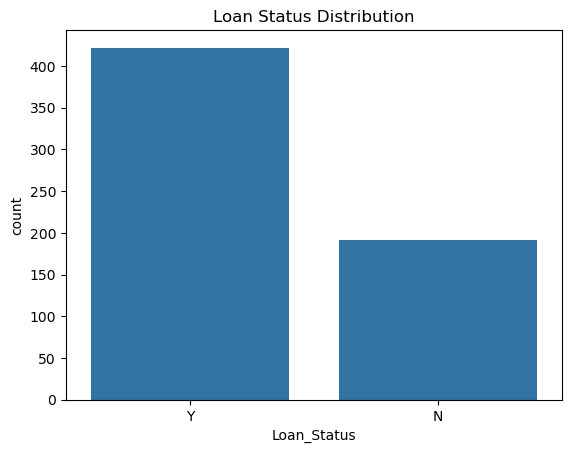

In [11]:
sns.countplot(x='Loan_Status', data=train_data)
plt.title('Loan Status Distribution')
plt.show()

Text(0.5, 1.0, 'Applicant Income Distribution')

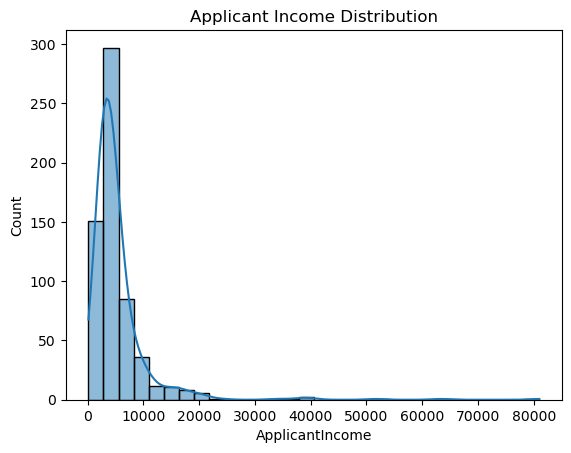

In [12]:
sns.histplot(x='ApplicantIncome', data=train_data, bins=30, kde=True)
plt.title('Applicant Income Distribution')

Text(0.5, 1.0, 'Co-Applicant Income Distribution')

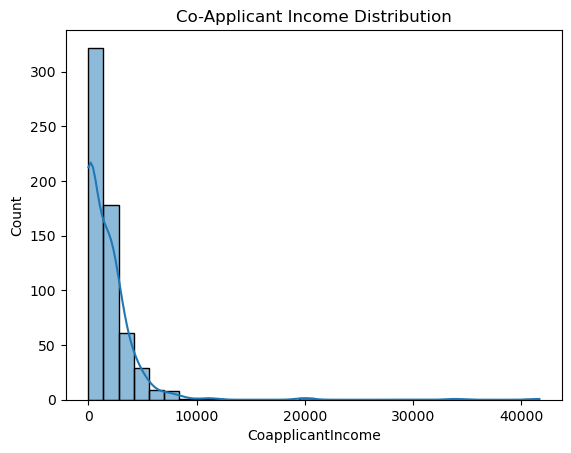

In [14]:
sns.histplot(x='CoapplicantIncome', data=train_data, bins=30, kde=True)
plt.title('Co-Applicant Income Distribution')

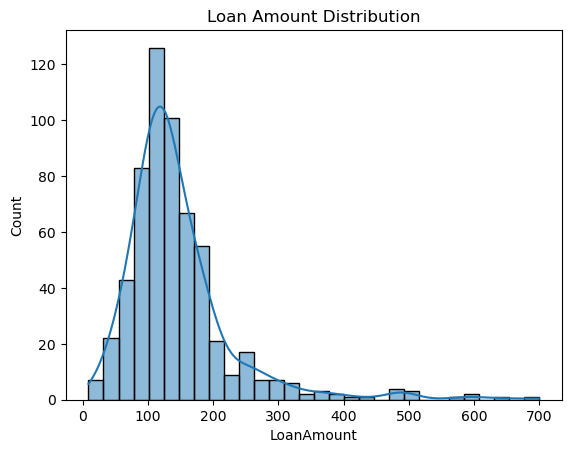

In [15]:
sns.histplot(data=train_data, x='LoanAmount', bins=30, kde=True)
plt.title('Loan Amount Distribution')
plt.show()

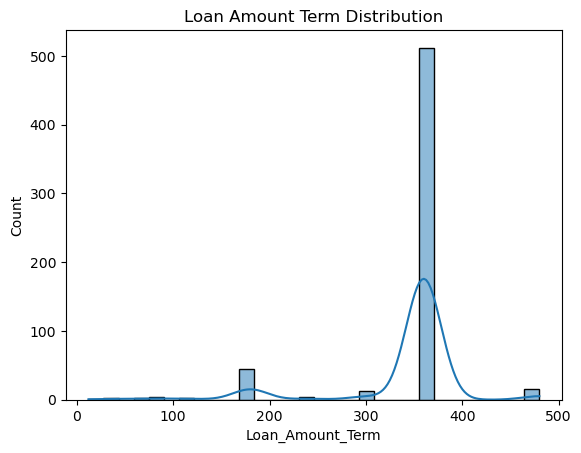

In [16]:
sns.histplot(data=train_data, x='Loan_Amount_Term', bins=30, kde=True)
plt.title('Loan Amount Term Distribution')
plt.show()

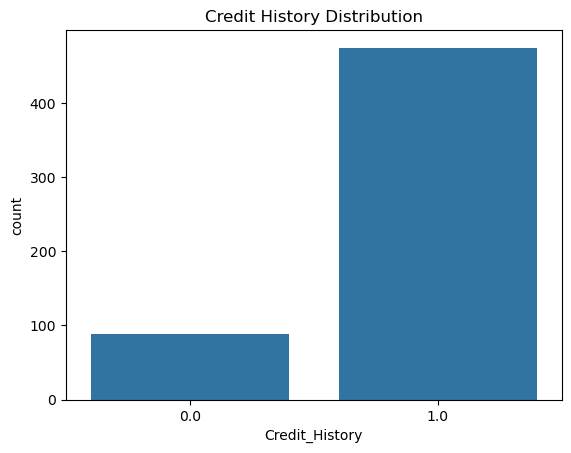

In [17]:
sns.countplot(data=train_data, x='Credit_History')
plt.title('Credit History Distribution')
plt.show()

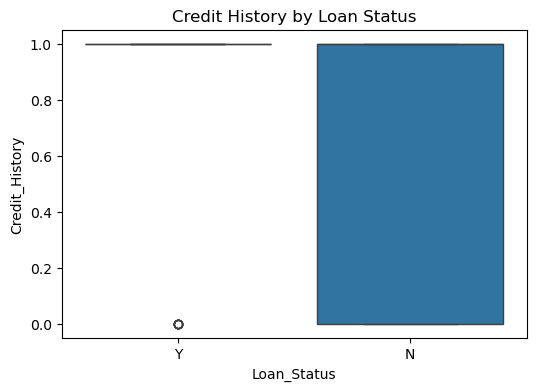

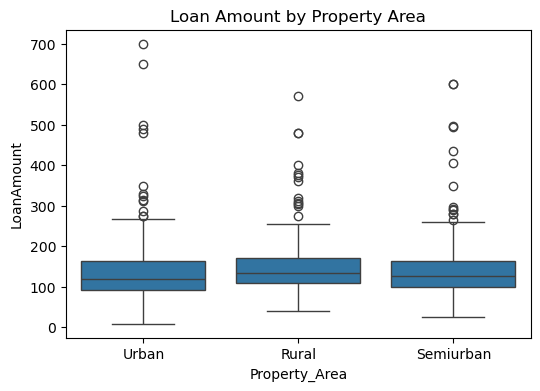

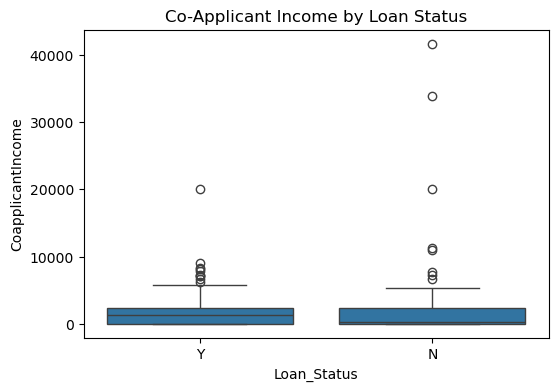

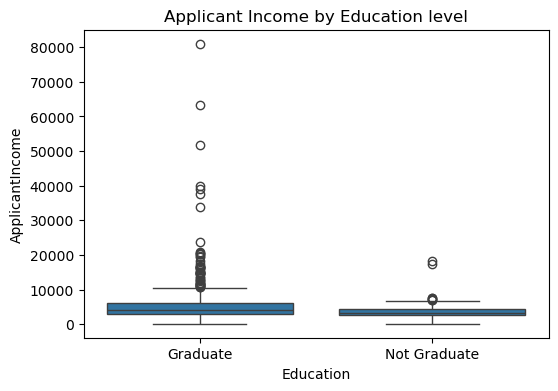

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(y='Credit_History', x='Loan_Status', data=train_data)
plt.title('Credit History by Loan Status')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Property_Area', y='LoanAmount', data=train_data)
plt.title('Loan Amount by Property Area')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Loan_Status', y='CoapplicantIncome', data=train_data)
plt.title('Co-Applicant Income by Loan Status')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Education', y='ApplicantIncome', data=train_data)
plt.title('Applicant Income by Education level')
plt.show()

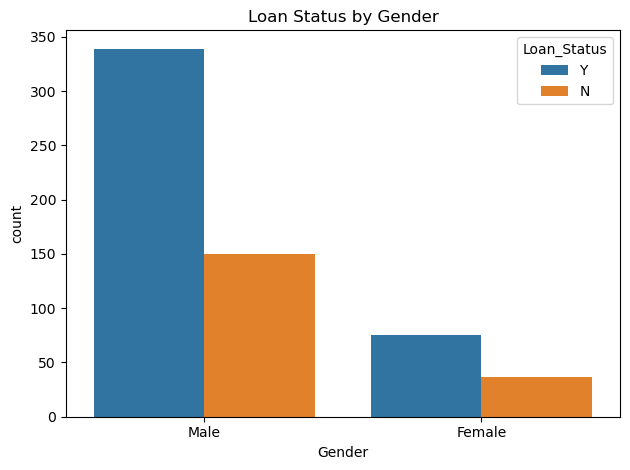

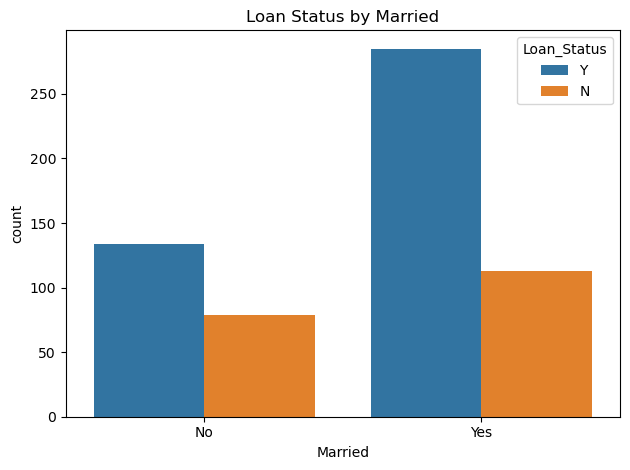

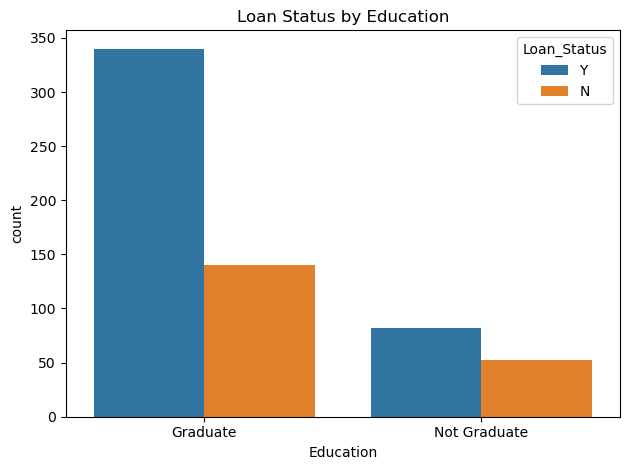

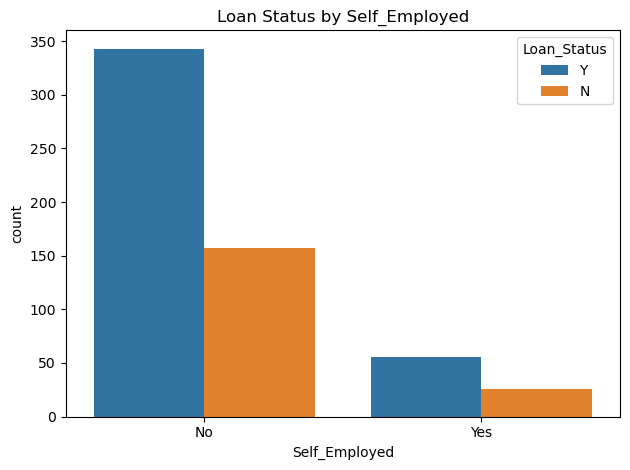

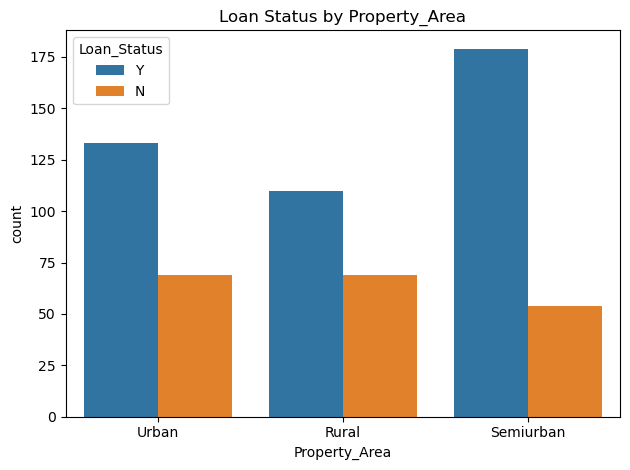

In [26]:
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
for col in categorical_cols:
    sns.countplot(data=train_data, x=col, hue='Loan_Status')
    plt.title(f'Loan Status by {col}')
    plt.tight_layout()
    plt.show()

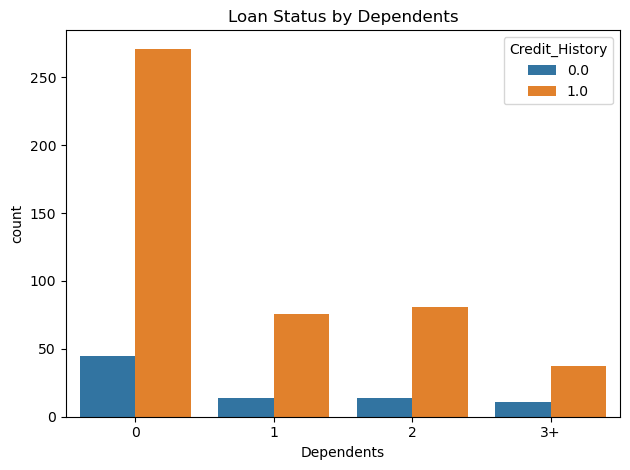

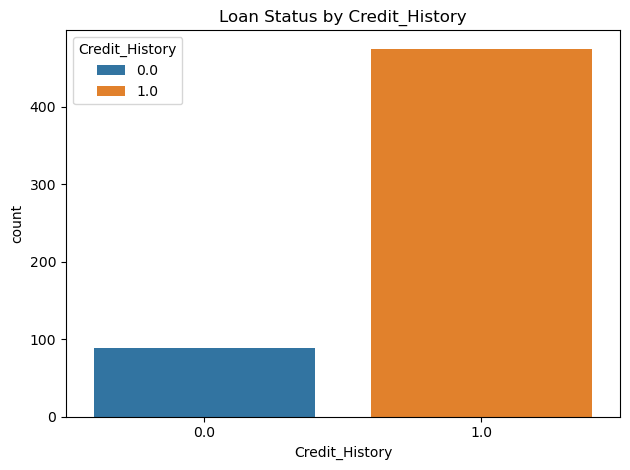

In [28]:
categorical_like = ['Dependents', 'Credit_History']
for col in categorical_like:
    sns.countplot(data=train_data, x=col, hue='Credit_History')
    plt.title(f'Loan Status by {col}')
    plt.tight_layout()
    plt.show()

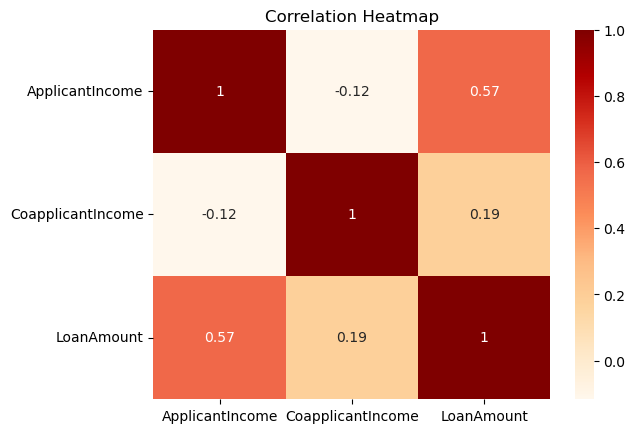

In [32]:
numeric_cols = train_data[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='OrRd')
plt.title('Correlation Heatmap')
plt.show()

In [19]:
train_data_org = pd.read_excel('/Users/vrishab.m.w/Downloads/train_project3.xlsx')

In [20]:
train_data['Gender'] = train_data_org['Gender']

In [24]:
train_data['Gender'] = train_data['Gender'].fillna(train_data['Gender'].mode()[0])

In [25]:
train_data['Gender']

0        Male
1        Male
2        Male
3        Male
4        Male
        ...  
609    Female
610      Male
611      Male
612      Male
613    Female
Name: Gender, Length: 614, dtype: object

In [28]:
train_data['Married'] = train_data['Married'].fillna(train_data['Married'].mode()[0])

In [30]:
train_data['Dependents'] = train_data['Dependents'].fillna(train_data['Dependents'].mode()[0])

In [32]:
train_data['Self_Employed'] = train_data['Self_Employed'].fillna(train_data['Self_Employed'].mode()[0])

In [34]:
train_data['LoanAmount'] = train_data['LoanAmount'].fillna(train_data['LoanAmount'].median())

In [39]:
train_data['Loan_Amount_Term'] = train_data['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].mode()[0])

In [41]:
train_data['Credit_History'] = train_data['Credit_History'].fillna(train_data['Credit_History'].mode()[0])

In [44]:
train_data['Total_Income'] = train_data['ApplicantIncome'] + train_data['CoapplicantIncome']
train_data['Total_Income']

0      5849.0
1      6091.0
2      3000.0
3      4941.0
4      6000.0
        ...  
609    2900.0
610    4106.0
611    8312.0
612    7583.0
613    4583.0
Name: Total_Income, Length: 614, dtype: float64

In [45]:
import numpy as np
train_data['log_applicant_income'] = np.log1p(train_data['ApplicantIncome'])
train_data['log_loan_amount'] = np.log1p(train_data['LoanAmount'])
train_data['log_total_income'] = np.log1p(train_data['Total_Income'])

In [46]:
train_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,log_applicant_income,log_loan_amount,log_total_income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,8.674197,4.859812,8.674197
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,8.430327,4.859812,8.714732
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,8.006701,4.204693,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,7.857094,4.795791,8.505525
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,8.699681,4.955827,8.699681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0,7.972811,4.276666,7.972811
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0,8.320448,3.713572,8.320448
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0,8.996280,5.537334,9.025576
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0,8.933796,5.236442,8.933796


In [47]:
train_data['has_coapplicant'] = train_data['CoapplicantIncome'].apply(lambda x:1 if x > 0 else 0)

In [48]:
train_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,log_applicant_income,log_loan_amount,log_total_income,has_coapplicant
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,8.674197,4.859812,8.674197,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,8.430327,4.859812,8.714732,1
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,8.006701,4.204693,8.006701,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,7.857094,4.795791,8.505525,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,8.699681,4.955827,8.699681,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0,7.972811,4.276666,7.972811,0
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0,8.320448,3.713572,8.320448,0
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0,8.996280,5.537334,9.025576,1
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0,8.933796,5.236442,8.933796,0


In [49]:
train_data = pd.get_dummies(train_data[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Amount_Term']], drop_first=True)

In [50]:
train_data

,Loan_Amount_Term,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,360.0,True,False,False,False,False,False,False,False,True
1,360.0,True,True,True,False,False,False,False,False,False
2,360.0,True,True,False,False,False,False,True,False,True
3,360.0,True,True,False,False,False,True,False,False,True
4,360.0,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
609,360.0,False,False,False,False,False,False,False,False,False
610,180.0,True,True,False,False,True,False,False,False,False
611,360.0,True,True,True,False,False,False,False,False,True
612,360.0,True,True,False,True,False,False,False,False,True


In [51]:
train_data.columns

Index(['Loan_Amount_Term', 'Gender_Male', 'Married_Yes', 'Dependents_1',
       'Dependents_2', 'Dependents_3+', 'Education_Not Graduate',
       'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')

In [60]:
train_data = pd.read_excel('/Users/vrishab.m.w/Downloads/train_project3.xlsx')
train_data['Gender'].fillna(train_data['Gender'].mode()[0])
train_data['Married'].fillna(train_data['Married'].mode()[0])
train_data['Dependents'].fillna(train_data['Dependents'].mode()[0])
train_data['Self_Employed'].fillna(train_data['Self_Employed'].mode()[0])
train_data['LoanAmount'].fillna(train_data['LoanAmount'].median())
train_data['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].mode()[0])
train_data['Credit_History'].fillna(train_data['Credit_History'].mode()[0])

train_data['total_income'] = train_data['ApplicantIncome'] + train_data['CoapplicantIncome']
train_data['log_total_income'] = np.log1p(train_data['total_income'])
train_data['log_loan_amount'] = np.log1p(train_data['LoanAmount'])
train_data['has_coapplicant'] = train_data['CoapplicantIncome'].apply(lambda x: 1 if x > 0 else 0)

train_data.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'total_income'], axis=1, inplace=True)

cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents', 'Loan_Amount_Term']
train_data = pd.get_dummies(train_data, columns=cat_cols, drop_first=True)

train_data['Loan_Status'] = train_data['Loan_Status'].map({'Y': 1, 'N': 0})

In [61]:
train_data

,Loan_ID,Credit_History,Loan_Status,log_total_income,log_loan_amount,has_coapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,...,Dependents_3+,Loan_Amount_Term_36.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0,Loan_Amount_Term_120.0,Loan_Amount_Term_180.0,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0
0,LP001002,1.0,1,8.674197,NaN,0,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,LP001003,1.0,0,8.714732,4.859812,1,True,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,LP001005,1.0,1,8.006701,4.204693,0,True,True,False,True,...,False,False,False,False,False,False,False,False,True,False
3,LP001006,1.0,1,8.505525,4.795791,1,True,True,True,False,...,False,False,False,False,False,False,False,False,True,False
4,LP001008,1.0,1,8.699681,4.955827,0,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,1.0,1,7.972811,4.276666,0,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
610,LP002979,1.0,1,8.320448,3.713572,0,True,True,False,False,...,True,False,False,False,False,True,False,False,False,False
611,LP002983,1.0,1,9.025576,5.537334,1,True,True,False,False,...,False,False,False,False,False,False,False,False,True,False
612,LP002984,1.0,1,8.933796,5.236442,0,True,True,False,False,...,False,False,False,False,False,False,False,False,True,False


In [67]:
train_data.isna().sum()

Loan_ID                     0
Credit_History             50
Loan_Status                 0
log_total_income            0
log_loan_amount            22
has_coapplicant             0
Gender_Male                 0
Married_Yes                 0
Education_Not Graduate      0
Self_Employed_Yes           0
Property_Area_Semiurban     0
Property_Area_Urban         0
Dependents_1                0
Dependents_2                0
Dependents_3+               0
Loan_Amount_Term_36.0       0
Loan_Amount_Term_60.0       0
Loan_Amount_Term_84.0       0
Loan_Amount_Term_120.0      0
Loan_Amount_Term_180.0      0
Loan_Amount_Term_240.0      0
Loan_Amount_Term_300.0      0
Loan_Amount_Term_360.0      0
Loan_Amount_Term_480.0      0
dtype: int64

In [70]:
train_data['Credit_History'] = train_data['Credit_History'].fillna(train_data['Credit_History'].mode()[0])
train_data['log_loan_amount'] = train_data['log_loan_amount'].fillna(train_data['log_loan_amount'].median())

In [71]:
train_data.isna().sum()

Loan_ID                    0
Credit_History             0
Loan_Status                0
log_total_income           0
log_loan_amount            0
has_coapplicant            0
Gender_Male                0
Married_Yes                0
Education_Not Graduate     0
Self_Employed_Yes          0
Property_Area_Semiurban    0
Property_Area_Urban        0
Dependents_1               0
Dependents_2               0
Dependents_3+              0
Loan_Amount_Term_36.0      0
Loan_Amount_Term_60.0      0
Loan_Amount_Term_84.0      0
Loan_Amount_Term_120.0     0
Loan_Amount_Term_180.0     0
Loan_Amount_Term_240.0     0
Loan_Amount_Term_300.0     0
Loan_Amount_Term_360.0     0
Loan_Amount_Term_480.0     0
dtype: int64

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = train_data.drop(['Loan_Status', 'Loan_ID'], axis=1)
y = train_data['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight = 'balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [76]:
y_pred = model.predict(X_test_scaled)

In [78]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy:  0.7967479674796748
Confusion Matrix:
 [[25 13]
 [12 73]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.66      0.67        38
           1       0.85      0.86      0.85        85

    accuracy                           0.80       123
   macro avg       0.76      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123



In [79]:
cm = confusion_matrix(y_test, y_pred)

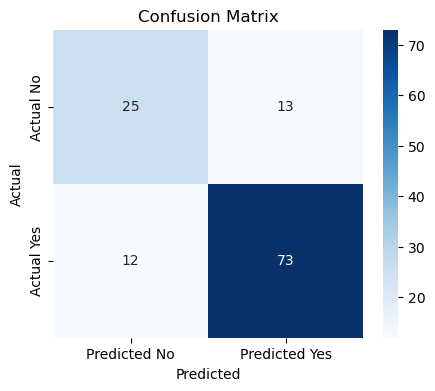

In [88]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [91]:
from sklearn.metrics import roc_curve, auc
y_pred_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
roc_auc

np.float64(0.8408668730650155)

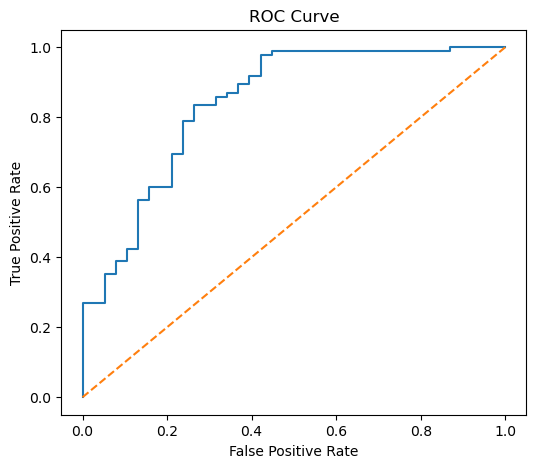

In [101]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()